# Intervalos de Confiança

---

Esse notebook é relacionado à aula:
https://www.youtube.com/watch?v=AkmyfLc-EOs

O que é um Intervalo de Confiança?

Diferente da estimação pontual, que fornece um único valor, o intervalo de confiança fornece uma **faixa de valores plausíveis** para um parâmetro populacional (como a média $\mu$) com base em uma amostra.

**Variabilidade**

Como as estimativas variam de uma amostra para outra (flutuação estatística), o intervalo de confiança ajuda a **quantificar a incerteza** do estimador.

Ou seja:  
Não confiamos em um único valor - consideramos um intervalo onde o parâmetro provavelmente está.

**Comprimento do Intervalo**

O tamanho do intervalo depende principalmente do tamanho da amostra $n$:

- Quanto maior $n$ → menor o intervalo  
- Quanto menor o intervalo → menor a incerteza  

Intuição:  
Mais dados → estimativa mais precisa → intervalo mais estreito

Vamos mostrar a distribuição do estimador do parâmetro $\theta$ da distribuição exponencial considerando diversas amostras de tamanho fixo. Logo, vamos que a estimação pontual não é suficiente para caracterizar o estimador.

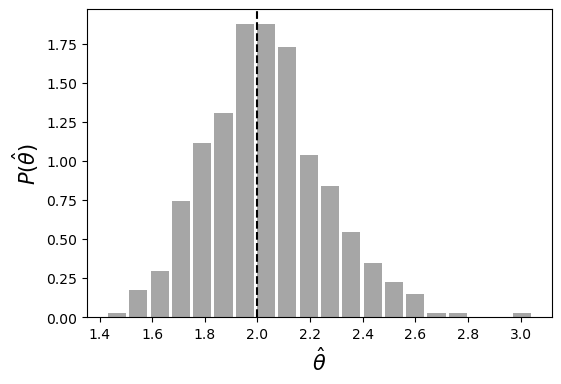

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2011)

theta = 2 # parâmetro do modelo exponencial
n = 100 # tamanho da amostra
ns = 500 # número de amostras
v_theta_hat = []
for s in range(0,ns):
    # sorteia uma amostra de tamanho n
    x = np.random.exponential(1/theta, n)
    # usa o estimador da exponencial
    theta_hat = n/np.sum(x)
    # armazena o valor estimado
    v_theta_hat.append(theta_hat)

# mostra os resultados da simulação
plt.figure(figsize=(6,4))
plt.hist(x=v_theta_hat, bins=20,color='gray',
         alpha=0.7, rwidth=0.85, density = True)
plt.xlabel(r'$\hat{\theta}$', fontsize=15)
plt.ylabel(r'$P(\hat{\theta})$', fontsize=15)
plt.axvline(x=theta, color='k', linestyle='--')
plt.show(True)

Podemos interpretaro intervalo de confiança de $(1-\alpha)100\%$ através de simulações.

Nível de confianca: 0.95
Fração de intervalos que contém a média: 0.95


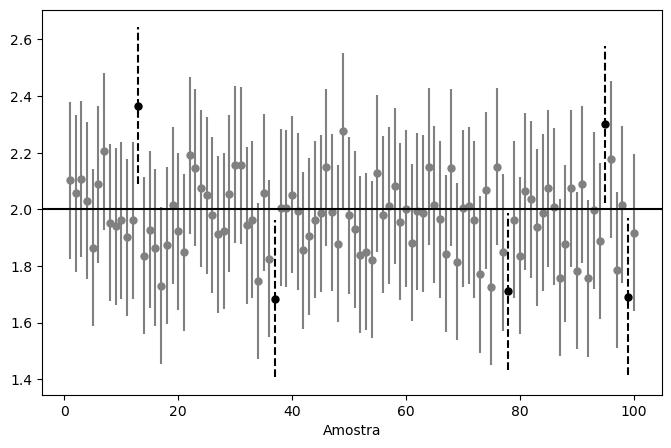

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
np.random.seed(10)

n = 50 # tamanho da amostra
Ns = 100 # número de intervalos
mu = 2 # média populacional
sigma = 1 # desvio padrão populacional
confidence = 0.95 # nível de confiança
# obtem zalpha/2 (tabelado)
zalpha = abs(scipy.stats.norm.ppf((1 - confidence)/2.))
c = 0 # conta o número de intervalos que contém a média
plt.figure(figsize=(8,5))
for s in range(1,Ns+1):
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n)
    # calcula o intervalo inferior
    IC1 = np.mean(x) - zalpha*sigma/np.sqrt(n)
    # calcula o intervalo superior
    IC2 = np.mean(x) + zalpha*sigma/np.sqrt(n)
    if(mu > IC1 and mu < IC2):
        c =  c + 1
        # mostra o intervalo que contém a media
        plt.vlines(s, ymin=IC1, ymax=IC2, color = 'gray')
        plt.plot(s,np.mean(x), 'o', color = 'gray',
                 markersize=5)
    else:
        # mostra o intervalo que não contem a média
        plt.vlines(s, ymin=IC1, ymax=IC2,
                   color = 'black', linestyles = 'dashed')
        plt.plot(s,np.mean(x), 'o', color = 'black',
                 markersize=5)

print('Nível de confianca:', confidence)
print('Fração de intervalos que contém a média:', c/Ns)
# mostra a média populacional
plt.axhline(y = mu, color = 'black')
plt.xlabel('Amostra', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.savefig('ic-sim.svg')
plt.show()

In [4]:
import scipy.stats
n = 23
alpha = 0.001
df = n-1 #grau de liberdade
print(scipy.stats.t.ppf(1-(alpha), df))

3.504992031084661


---
## Calculo do Intervalo de confiança

Podemos implementar uma função para calcular o intervalo de confiança automaticamente.

In [5]:
import scipy.stats
import numpy as np

def confident_interval(Xs, n, confidence = 0.95,
                       sigma = -1, s = -1):
    alpha = (1 - confidence)/2.
    zalpha = abs(scipy.stats.norm.ppf(alpha))
    if(sigma != -1): # se a variância é conhecida
        IC1 = Xs - zalpha*sigma/np.sqrt(n)
        IC2 = Xs + zalpha*sigma/np.sqrt(n)
    else: # se a variância é desconhecida
        if(n >= 50): # se o tamanho da amostra > 50
            # Use a distribuição normal
            IC1 = Xs - zalpha*s/np.sqrt(n)
            IC2 = Xs + zalpha*s/np.sqrt(n)
        else: # se o tamanho da amostra é < 50
            # Use a distribuição t de Student
            talpha = scipy.stats.t.ppf((1 + confidence) / 2., n-1)
            IC1 = Xs - talpha*s/np.sqrt(n)
            IC2 = Xs + talpha*s/np.sqrt(n)
    # retorna o intervalo de confiança
    return [IC1, IC2]

**Exemplo**: Em uma empresa de distribuição de alimentos pela internet, verificou-se que o tempo necessário para uma entrega tem distribuição normal com média $\mu = 30$ minutos e desvio padrão $\sigma = 10$ minutos. Em uma amostra de 50 entregadores, observou-se um tempo médio de entrega $\bar{X}_{50} = 25$ minutos. Determine o intervalo de 95\% de confiança para a média $\mu$ de todos os entregadores da empresa.

In [6]:
Xs = 25 # média amostral
n = 50 # tamanho da amostra
confidence =0.95 # nível de confiança
sigma = 10 # desvio padrão populacional
IC = confident_interval(Xs,n, confidence, sigma)
print('Intervalo de confiança:', IC)

Intervalo de confiança: [22.228192351300645, 27.771807648699355]


**Exemplo:** Em uma escola, acredita-se que as notas dos alunos tem uma distribuição normal com média $\mu=7,5$ e desvio padrão $\sigma = 1$. Uma amostra de 100 alunos forneceu $\bar{X}_{100} = 8,0$. Determine o intervalo de 99\% de confiança para a média $\mu$ de todos os alunos da escola.

In [7]:
import scipy.stats
import numpy as np
Xn = 8
sigma = 1
n = 100
confidence =0.99
alpha = 1 - confidence
zalpha = abs(scipy.stats.norm.ppf((1 - confidence)/2.))
IC1 = Xn - zalpha*sigma/np.sqrt(n)
IC2 = Xn + zalpha*sigma/np.sqrt(n)
print('IC:[', IC1,';', IC2,']')

IC:[ 7.74241706964511 ; 8.25758293035489 ]


Usando a função que desenvolvemos:

In [8]:
Xs = 7.5
sigma = 1
n = 100
confidence =0.99
IC = confident_interval(Xn,n, confidence, sigma)
print('Confidence interval:', IC)

Confidence interval: [7.74241706964511, 8.25758293035489]


**Exemplo** -  Em um provedor de vídeos na Internet, verificou-se que para uma amostra de 15 usuários, o tempo médio de exibição é igual a $\bar{X}_{15} = 39,3$ minutos e o desvio padrão da amostra $S_{15} = 2,6$ minutos. Encontre um intervalo de 90\% para a média populacional $\mu$.

In [17]:
import scipy.stats
import numpy as np

Xn = 39.3 # média amostral
s = 2.6 # desvio padrão amostral
n = 15 # tamanho da amostra
confidence =0.9 # nível de confiança
alpha = 1 - confidence
df = n-1 #grau de liberdade
talpha = scipy.stats.t.ppf(1-(alpha/2), df)
IC1 = Xn - talpha*s/np.sqrt(n)
IC2 = Xn + talpha*s/np.sqrt(n)
print('IC:[', IC1,';', IC2,']')

IC:[ 38.117602363950525 ; 40.48239763604947 ]


Usando a função anterior:

In [10]:
IC = confident_interval(Xn,n, confidence,s = s)
print('Confidence interval:', IC)

Confidence interval: [38.117602363950525, 40.48239763604947]


### Conjunto de dados

Para um conjunto de dados, temos a função abaixo.

In [11]:
import scipy.stats
import numpy as np

def confident_interval_data(X, confidence = 0.95, sigma = -1):
    # função para calcular o desvio padrão amostral
    def S(X):
        s = 0
        # calcula o desvio padrão amostral
        for i in range(0,len(X)):
            s = s + (X[i] - np.mean(X))**2
        s = np.sqrt(s/(len(X)-1))
        return s
    n = len(X) # número de elementos na amostra
    Xs = np.mean(X) # média amostral
    s = S(X) # desvio padrão amostral
    zalpha = abs(scipy.stats.norm.ppf((1 - confidence)/2))
    if(sigma != -1): # se a variância é conhecida
        IC1 = Xs - zalpha*sigma/np.sqrt(n)
        IC2 = Xs + zalpha*sigma/np.sqrt(n)
    else: # se a variância é desconhecida
        if(n >= 50): # se o tamanho da amostra é > 50
            # Usa a distribuição normal
            IC1 = Xs - zalpha*s/np.sqrt(n)
            IC2 = Xs + zalpha*s/np.sqrt(n)
        else: # se o tamanho da amostra é < 50
            # Use a distribuição t de Student
            talpha = scipy.stats.t.ppf((1 + confidence) / 2., n-1)
            IC1 = Xs - talpha*s/np.sqrt(n)
            IC2 = Xs + talpha*s/np.sqrt(n)
    return [IC1, IC2]

Executando para um exemplo.

In [12]:
X = [1, 2, 3, 4, 5]
confidence = 0.95
IC = confident_interval_data(X, confidence)
print('IC:', IC)

IC: [1.0367568385224393, 4.9632431614775605]


**Exemplos:** Considere os dados da flor iris.  Construa um inverlo de confiança de 90\% para o comprimento da pétala, para cada uma das espécies.

In [13]:
import matplotlib.pyplot as plt
from sklearn import datasets
import scipy.stats

def confident_interval_data(X, confidence = 0.95,
                            sigma = -1):
    # função que calcula o desvio padrão amostral
    def S(X):
        s = 0
        for i in range(0,len(X)):
            s = s + (X[i] - np.mean(X))**2
        s = np.sqrt(s/(len(X)-1))
        return s
    n = len(X) # número de elementos na amostra
    Xs = np.mean(X) # média amostral
    s = S(X) # desvio padrão amostral
    zalpha = abs(scipy.stats.norm.ppf((1 - confidence)/2))
    if(sigma != -1): # se a variância é conhecida
        IC1 = Xs - zalpha*sigma/np.sqrt(n)
        IC2 = Xs + zalpha*sigma/np.sqrt(n)
    else: # se a variância é desconhecida
        if(n >= 50): # se o tamanho da amostra é > 50
            # Usa a distribuição normal
            IC1 = Xs - zalpha*s/np.sqrt(n)
            IC2 = Xs + zalpha*s/np.sqrt(n)
        else: # se o tamanho da amostra é < 50
            # Use a distribuição t de Student
            talpha = scipy.stats.t.ppf((1 + confidence) / 2., n-1)
            IC1 = Xs - talpha*s/np.sqrt(n)
            IC2 = Xs + talpha*s/np.sqrt(n)
    return [IC1, IC2]

# leitura dos dados
iris = datasets.load_iris()
variables = iris.feature_names
species = iris.target_names
print('Variáveis:', variables)
# o comprimento da pétala é a terceira variável
data = iris.data[:,2]
y = iris.target

for c in range(0,3):
    print('*****************')
    print('Espécie:', species[c])
    X = data[y == c]
    IC = confident_interval_data(X, confidence=0.9)
    print('IC:', IC)

Variáveis: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
*****************
Espécie: setosa
IC: [1.4216027273275496, 1.5023972726724508]
*****************
Espécie: versicolor
IC: [4.15069051580011, 4.369309484199889]
*****************
Espécie: virginica
IC: [5.423619673858185, 5.680380326141816]


---
## Bootstrapping

O Bootstrap é um método de **reamostragem com reposição** usado quando:

- A população não segue uma distribuição normal  
- Queremos estimar parâmetros mais complexos (ex: mediana)  

Ele permite estimar a distribuição de um estimador **sem depender de fórmulas analíticas**.

Procedimento

1. A partir da amostra original de tamanho $n$, sorteamos uma nova amostra (com reposição)  
2. Repetimos esse processo várias vezes (ex: $10^4$ vezes)  
3. Calculamos o estimador (ex: média, mediana) para cada amostra  
4. Construímos a distribuição dos estimadores  

Intervalo de Confiança com Bootstrap

Após gerar várias estimativas, usamos os **percentis** da distribuição:

- Percentil 2.5% → limite inferior  
- Percentil 97.5% → limite superior  

Isso forma um intervalo de confiança aproximado

Intuição Final

- Reutiliza os dados disponíveis  
- Simula várias "realidades possíveis"  
- Estima incerteza sem assumir distribuição  

Em Data Science:
Bootstrap é muito usado quando:
- o modelo é complexo  
- a distribuição é desconhecida  
- queremos validar estimativas de forma robusta

IC: [ 9.212847614401628 10.420260245572951 ]


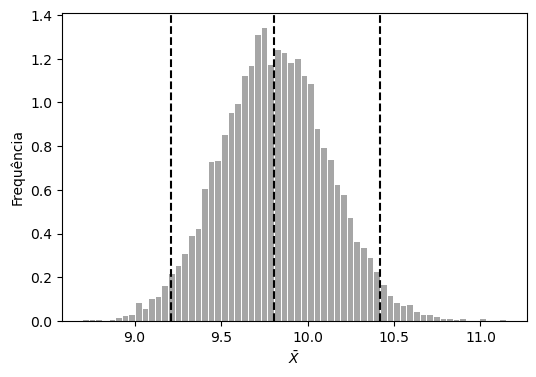

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2011)

# gera os dados que serão amostrados
# esses dados podem ser simulados ou
# lidos de um arquivo
mu = 10 # média populacional
sigma = 5 # desvio padrão
n = 1000 # tamanho da amostra
#X = np.random.normal(mu, sigma, n)
X = np.random.exponential(scale=mu, size = n)

#Bootstrapping: sorteia ns amostras
ns = 10000
theta_hat = []
for i in range(0,ns):
    # amostra n elementos de X
    s = np.random.choice(X, n, replace=True)
    theta_hat.append(np.mean(s))

# calcula a mediana
median = np.percentile(theta_hat, 50)
# calcula o intervalo de confiança
confidence = 95
alpha = 100-confidence
lower_ci = np.percentile(theta_hat, alpha/2)
upper_ci = np.percentile(theta_hat, 100-alpha/2)
print('IC: [',lower_ci, upper_ci,']')
# mostra os resultados
plt.figure(figsize=(6,4))
plt.hist(x=theta_hat, bins='auto',color='gray', alpha=0.7, rwidth=0.85, density = True)
plt.axvline(median,0, 14, linestyle="--", color="black")
plt.axvline(lower_ci,0, 14, linestyle="--", color="black")
plt.axvline(upper_ci,0, 14, linestyle="--", color="black")
plt.xlabel(r'$\bar{X}$', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.savefig('boostrap.svg')
plt.show(True)

In [15]:
theta_hat

[9.65664387627847,
 9.967686683063276,
 10.32973992094399,
 10.18090354323538,
 9.748237872754515,
 9.854190931577028,
 9.567245246157437,
 10.177186163159076,
 10.117250621755302,
 9.834307678382082,
 10.193135824312842,
 10.231571445645882,
 9.547211800352882,
 9.889378054892084,
 10.318341609470304,
 9.775889342945797,
 9.543161569563676,
 10.340099750029669,
 10.37865521655967,
 9.90880396924388,
 9.779342091390905,
 9.549725212438519,
 10.011888022688844,
 10.088207647291897,
 10.429144966106225,
 9.970304880841669,
 10.445695424687724,
 9.453998078333091,
 9.490110029475469,
 10.166923767454522,
 9.687556440138232,
 9.699081625857971,
 9.494456384056651,
 10.062925848730908,
 9.62952698326836,
 9.219109851113336,
 10.492884413391634,
 9.947643089694068,
 9.612629208158836,
 9.705507219696607,
 9.714098266062484,
 9.911494275218232,
 10.539703666674887,
 10.22486179679131,
 9.29680350288865,
 10.067271934357798,
 9.802696918694979,
 9.088454920018721,
 9.913833320526585,
 9.624844

Boostrapping aplicado aos dados da flor iris:

Variáveis: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
*****************
Espécie: setosa
IC: [ 1.416 1.51 ]


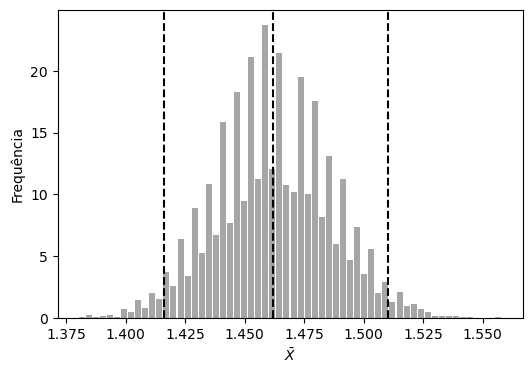

*****************
Espécie: versicolor
IC: [ 4.128 4.388 ]


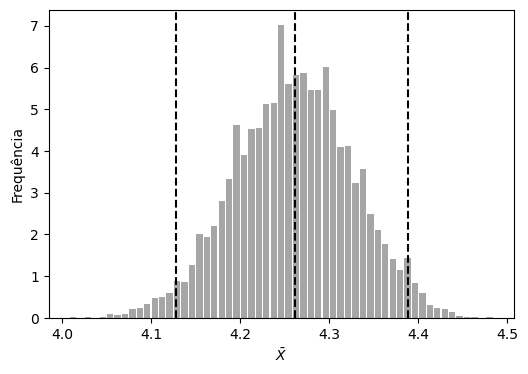

*****************
Espécie: virginica
IC: [ 5.406000000000001 5.707999999999999 ]


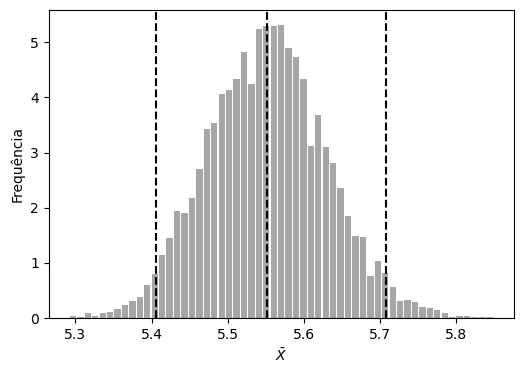

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()
variables = iris.feature_names
species = iris.target_names
print('Variáveis:', variables)
# o comprimento da pétala é a terceira variável
data = iris.data[:,2]
y = iris.target

for c in range(0,3): # para cada espécie da Iris
    print('*****************')
    print('Espécie:', species[c])
    X = data[y == c]
    n = X.size

    #Bootstrapping: sorteia ns amostras
    ns = 10000
    theta_hat = []
    for i in range(0,ns):
        # amostra n elementos da população
        s = np.random.choice(X, n, replace=True)
        theta_hat.append(np.mean(s))

    # calcula a mediana
    median = np.percentile(theta_hat, 50)
    # calcula o intervalo de confiança
    confidence = 95
    alpha = 100-confidence
    lower_ci = np.percentile(theta_hat, alpha/2)
    upper_ci = np.percentile(theta_hat, 100-alpha/2)
    print('IC: [',lower_ci, upper_ci,']')
    # mostra os resultados
    plt.figure(figsize=(6,4))
    plt.hist(x=theta_hat, bins='auto',color='gray',
             alpha=0.7, rwidth=0.85, density = True)
    plt.axvline(median,0, 14, linestyle="--", color="black")
    plt.axvline(lower_ci,0, 14, linestyle="--", color="black")
    plt.axvline(upper_ci,0, 14, linestyle="--", color="black")
    plt.xlabel(r'$\bar{X}$', fontsize=10)
    plt.ylabel('Frequência', fontsize=10)
    plt.savefig('boostrap.svg')
    plt.show(True)